# Pre-Analyze Signal — UrbanSound8K

Phan tich tin hieu 10 class am thanh moi truong de dua ra quyet dinh thiet ke he thong.

**4 phan chinh:**
1. **Signal Type** — Stationary vs Non-stationary (CV_RMS, Crest Factor)
2. **Frequency Characteristics** — Dominant freq, Bandwidth, DWT energy
3. **Noise Sources** — SNR, noise types, DSP impact
4. **Sampling Requirements** — Nyquist, window size, spectral leakage

In [44]:
# === Setup ===
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from scipy import signal as scipy_signal
import librosa
import librosa.display
import pywt
from IPython.display import display, HTML

import config
from src.data_loader import load_metadata, load_audio, get_file_path
from src.signal_analysis import (
    compute_fft, compute_psd, find_dominant_frequencies, compute_bandwidth,
    compute_amplitude_stats, check_stationarity, estimate_snr,
    compute_dwt_energy, compute_spectral_leakage
)

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

print("=" * 60)
print("DSP501 — Pre-Analyze Signal")
print("=" * 60)
print(f"Sample rate:  {config.TARGET_SR} Hz")
print(f"Duration:     {config.AUDIO_DURATION}s = {config.N_SAMPLES} samples")
print(f"N_FFT:        {config.N_FFT}")
print(f"Nyquist:      {config.TARGET_SR // 2} Hz")
print(f"Filter band:  {config.FILTER_LOW_FREQ}--{config.FILTER_HIGH_FREQ} Hz")

DSP501 — Pre-Analyze Signal
Sample rate:  22050 Hz
Duration:     4.0s = 88200 samples
N_FFT:        2048
Nyquist:      11025 Hz
Filter band:  50--10000 Hz


In [45]:
# === Load metadata + 1 sample per class ===
metadata = load_metadata()
print(f"Total samples: {len(metadata)}, Classes: {len(config.CLASS_NAMES)}")
print()

samples = {}
for cls_name in config.CLASS_NAMES:
    row = metadata[metadata['class'] == cls_name].iloc[0]
    file_path = get_file_path(row)
    y = load_audio(file_path)
    samples[cls_name] = y
    print(f"  {cls_name:20s}: {len(y)} samples, {len(y)/config.TARGET_SR:.2f}s")

print(f"\nLoaded 1 representative sample per class.")

Total samples: 8732, Classes: 10

  air_conditioner     : 88200 samples, 4.00s
  car_horn            : 88200 samples, 4.00s
  children_playing    : 88200 samples, 4.00s
  dog_bark            : 88200 samples, 4.00s
  drilling            : 88200 samples, 4.00s
  engine_idling       : 88200 samples, 4.00s
  gun_shot            : 88200 samples, 4.00s
  jackhammer          : 88200 samples, 4.00s
  siren               : 88200 samples, 4.00s
  street_music        : 88200 samples, 4.00s

Loaded 1 representative sample per class.


---
# PART 1: Signal Type — Stationary vs Non-Stationary

**Method**: CV_RMS (Coefficient of Variation of RMS)

$$CV = \frac{\sigma_{\text{RMS}}}{\mu_{\text{RMS}}}$$

- Chia tin hieu 4s thanh 8 doan (0.5s/doan), tinh RMS moi doan
- **CV < 0.3 -> Stationary** (nang luong on dinh)
- **CV >= 0.3 -> Non-stationary** (nang luong thay doi)

In [46]:
# === 1.1 Compute CV_RMS + Crest Factor + Amplitude Stats for all 10 classes ===

results_part1 = []

for cls_name in config.CLASS_NAMES:
    y = samples[cls_name]
    stat = check_stationarity(y, sr=config.TARGET_SR, segment_duration=0.5)
    amp = compute_amplitude_stats(y)

    results_part1.append({
        'Class': cls_name,
        'RMS': amp['rms'],
        'Peak': amp['peak'],
        'Crest Factor': amp['crest_factor'],
        'CV_RMS': stat['cv_rms'],
        'Type': 'Stationary' if stat['stationary'] else 'Non-stationary',
        'rms_segments': stat['rms_per_segment'],
    })

df_part1 = pd.DataFrame(results_part1)
df_part1 = df_part1.sort_values('CV_RMS').reset_index(drop=True)

print("=" * 90)
print("PART 1: Signal Type Classification (Stationary vs Non-stationary)")
print("=" * 90)
print(f"{'Class':20s} {'CV_RMS':>8s} {'Type':>16s} {'RMS':>8s} {'Peak':>8s} {'Crest Factor':>14s}")
print("-" * 90)
for _, row in df_part1.iterrows():
    marker = '***' if row['CV_RMS'] >= 0.3 else '   '
    print(f"{row['Class']:20s} {row['CV_RMS']:8.3f} {row['Type']:>16s} "
          f"{row['RMS']:8.4f} {row['Peak']:8.4f} {row['Crest Factor']:14.2f} {marker}")
print("-" * 90)
print(f"Threshold: CV_RMS < 0.3 -> Stationary, CV_RMS >= 0.3 -> Non-stationary")
n_stat = len(df_part1[df_part1['Type'] == 'Stationary'])
n_nonstat = len(df_part1[df_part1['Type'] == 'Non-stationary'])
print(f"Result: {n_stat} Stationary + {n_nonstat} Non-stationary = {n_stat + n_nonstat} classes")

PART 1: Signal Type Classification (Stationary vs Non-stationary)
Class                  CV_RMS             Type      RMS     Peak   Crest Factor
------------------------------------------------------------------------------------------
engine_idling           0.025       Stationary   0.1222   0.3257           2.67    
air_conditioner         0.052       Stationary   0.0972   0.7500           7.72    
street_music            0.080       Stationary   0.0491   0.2547           5.19    
jackhammer              0.083       Stationary   0.0323   0.1555           4.81    
siren                   0.142       Stationary   0.0453   0.2168           4.79    
children_playing        0.177       Stationary   0.0041   0.0271           6.54    
drilling                0.518   Non-stationary   0.1215   0.6506           5.36 ***
gun_shot                1.393   Non-stationary   0.0264   0.3697          13.99 ***
car_horn                1.923   Non-stationary   0.0174   0.1880          10.83 ***
dog_bar

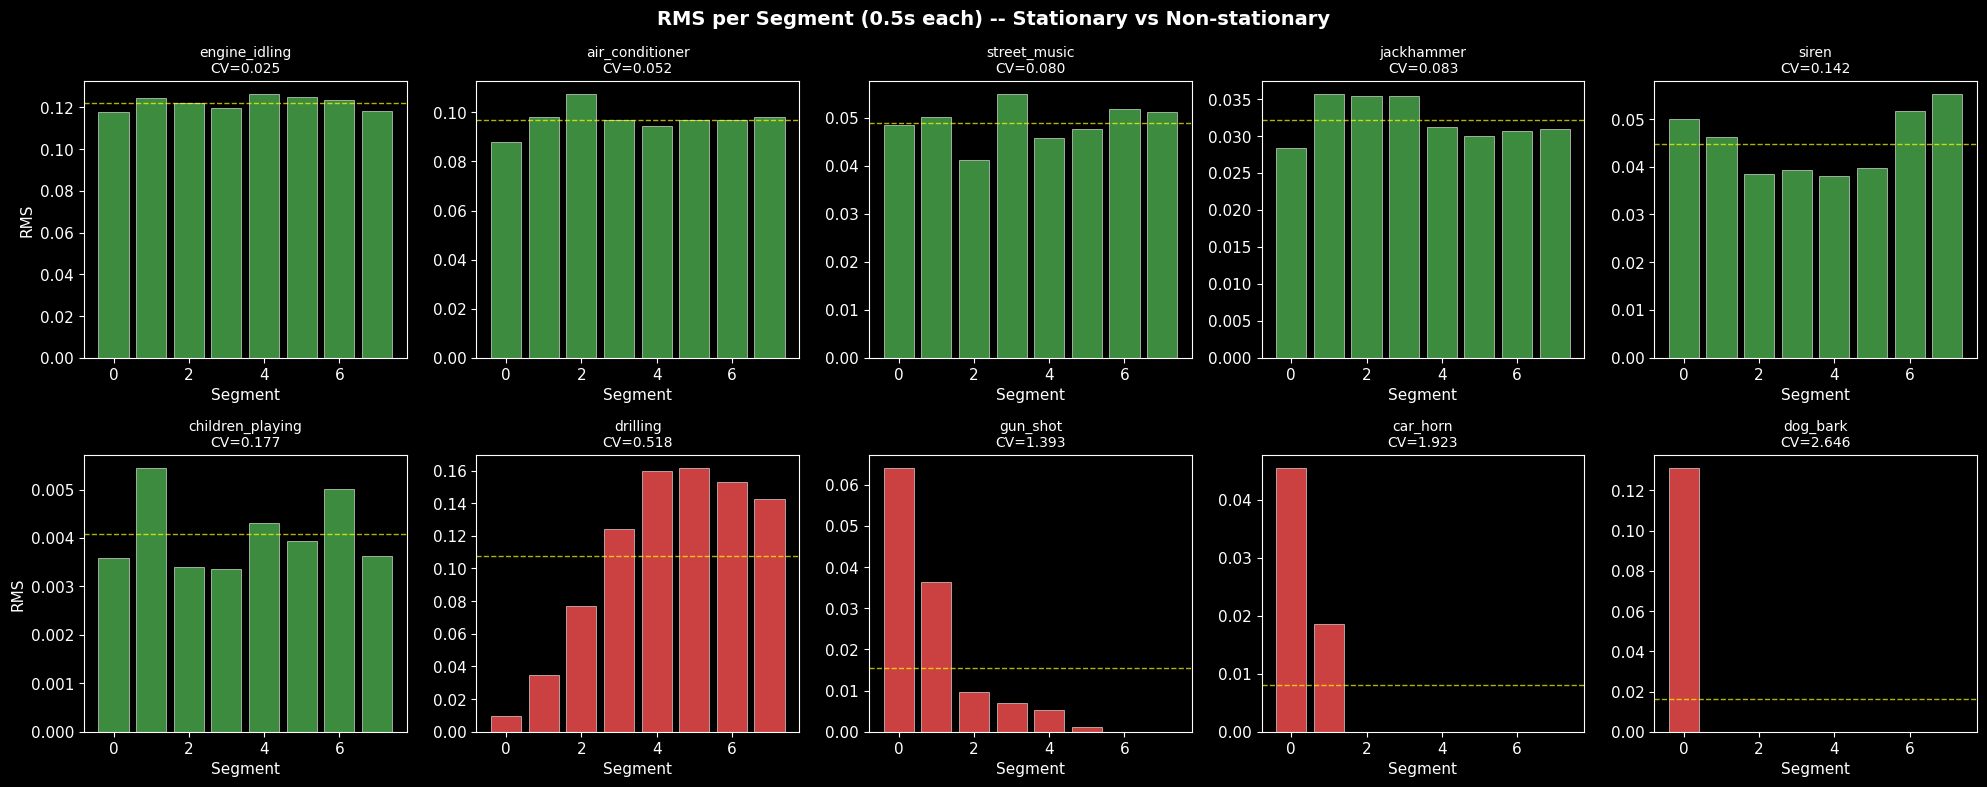

Green = Stationary (RMS stable), Red = Non-stationary (RMS varies)


In [47]:
# === 1.2 Visualize: RMS per segment for all classes ===

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
fig.suptitle('RMS per Segment (0.5s each) -- Stationary vs Non-stationary', fontsize=14, fontweight='bold')

for idx, (_, row) in enumerate(df_part1.iterrows()):
    ax = axes[idx // 5, idx % 5]
    segments = row['rms_segments']
    color = '#4CAF50' if row['Type'] == 'Stationary' else '#FF5252'
    ax.bar(range(len(segments)), segments, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_title(f"{row['Class']}\nCV={row['CV_RMS']:.3f}", fontsize=10)
    ax.set_xlabel('Segment')
    if idx % 5 == 0:
        ax.set_ylabel('RMS')
    mean_rms = np.mean(segments)
    ax.axhline(y=mean_rms, color='yellow', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.savefig('results/figures/fig_rms_per_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Green = Stationary (RMS stable), Red = Non-stationary (RMS varies)")

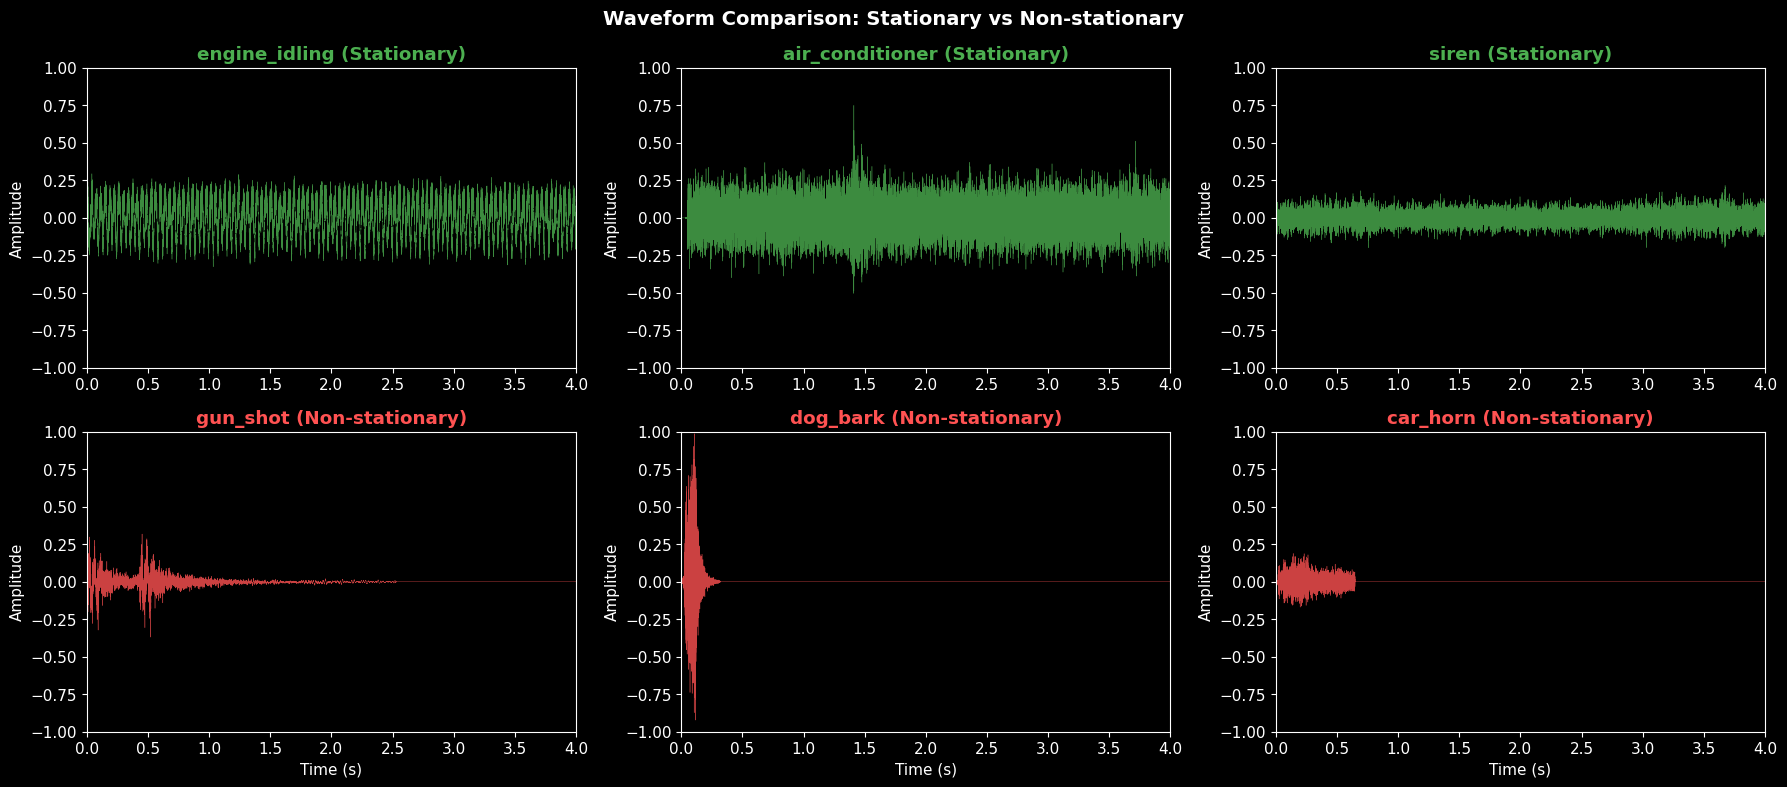

In [48]:
# === 1.3 Waveforms -- 3 stationary vs 3 non-stationary ===

stat_classes = ['engine_idling', 'air_conditioner', 'siren']
nonstat_classes = ['gun_shot', 'dog_bark', 'car_horn']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Waveform Comparison: Stationary vs Non-stationary', fontsize=14, fontweight='bold')
t = np.arange(config.N_SAMPLES) / config.TARGET_SR

for i, cls in enumerate(stat_classes):
    ax = axes[0, i]
    ax.plot(t, samples[cls], color='#4CAF50', linewidth=0.3, alpha=0.8)
    ax.set_title(f'{cls} (Stationary)', color='#4CAF50', fontweight='bold')
    ax.set_ylabel('Amplitude'); ax.set_xlim(0, 4); ax.set_ylim(-1, 1)

for i, cls in enumerate(nonstat_classes):
    ax = axes[1, i]
    ax.plot(t, samples[cls], color='#FF5252', linewidth=0.3, alpha=0.8)
    ax.set_title(f'{cls} (Non-stationary)', color='#FF5252', fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude'); ax.set_xlim(0, 4); ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('results/figures/fig_waveform_stat_vs_nonstat.png', dpi=150, bbox_inches='tight')
plt.show()

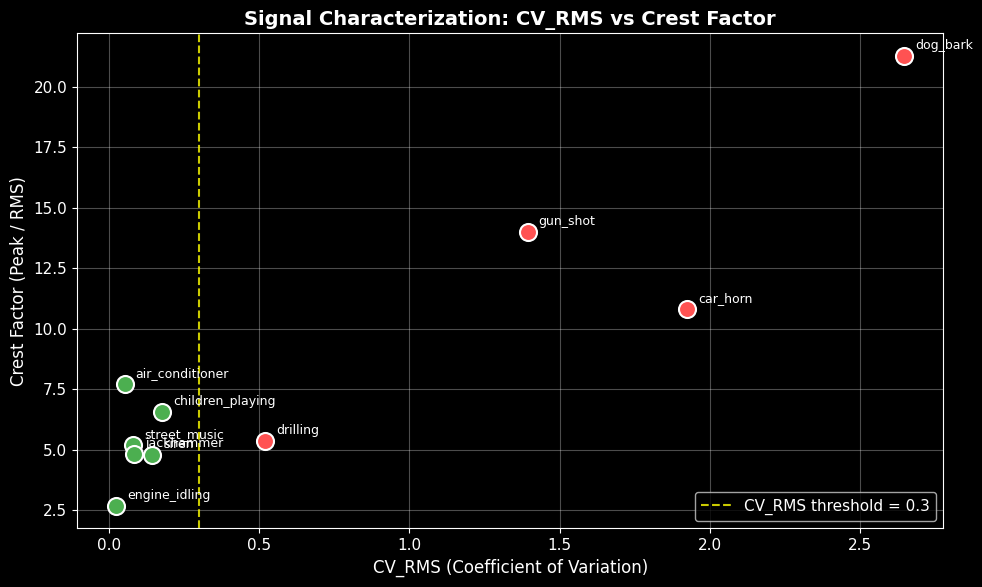

Non-stationary (red): high CV_RMS AND high Crest Factor


In [49]:
# === 1.4 Crest Factor vs CV_RMS scatter ===

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in df_part1.iterrows():
    color = '#4CAF50' if row['Type'] == 'Stationary' else '#FF5252'
    ax.scatter(row['CV_RMS'], row['Crest Factor'], s=150, color=color,
               edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate(row['Class'], (row['CV_RMS'], row['Crest Factor']),
                textcoords='offset points', xytext=(8, 5), fontsize=9, color='white')

ax.axvline(x=0.3, color='yellow', linestyle='--', linewidth=1.5, alpha=0.8, label='CV_RMS threshold = 0.3')
ax.set_xlabel('CV_RMS (Coefficient of Variation)', fontsize=12)
ax.set_ylabel('Crest Factor (Peak / RMS)', fontsize=12)
ax.set_title('Signal Characterization: CV_RMS vs Crest Factor', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/fig_cv_vs_crest_factor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Non-stationary (red): high CV_RMS AND high Crest Factor")

### Impact on System Design

| Design Decision | Stationary Classes | Non-stationary Classes |
|----------------|-------------------|----------------------|
| Feature extraction | MFCC mean captures spectral shape | Delta MFCC + Delta2 bat temporal dynamics |
| Statistical aggregation | Mean, median du | Std, skew, kurtosis quan trong |
| Time-frequency analysis | STFT du tot | CWT tot hon (adaptive resolution) |
| Filter choice | IIR hoac FIR deu OK | **FIR bat buoc** -- linear phase bao toan hinh dang xung |

-> **Quyet dinh**: Feature vector 931-dim = MFCC(40) x 3(goc+delta+delta2) x 7(stats) + spectral(42) + contrast(49)

---
# PART 2: Frequency Characteristics

- Dominant frequencies cho moi class
- Bandwidth (dai tan chua 90% nang luong)
- DWT energy distribution
- Cac cap class de nham lan

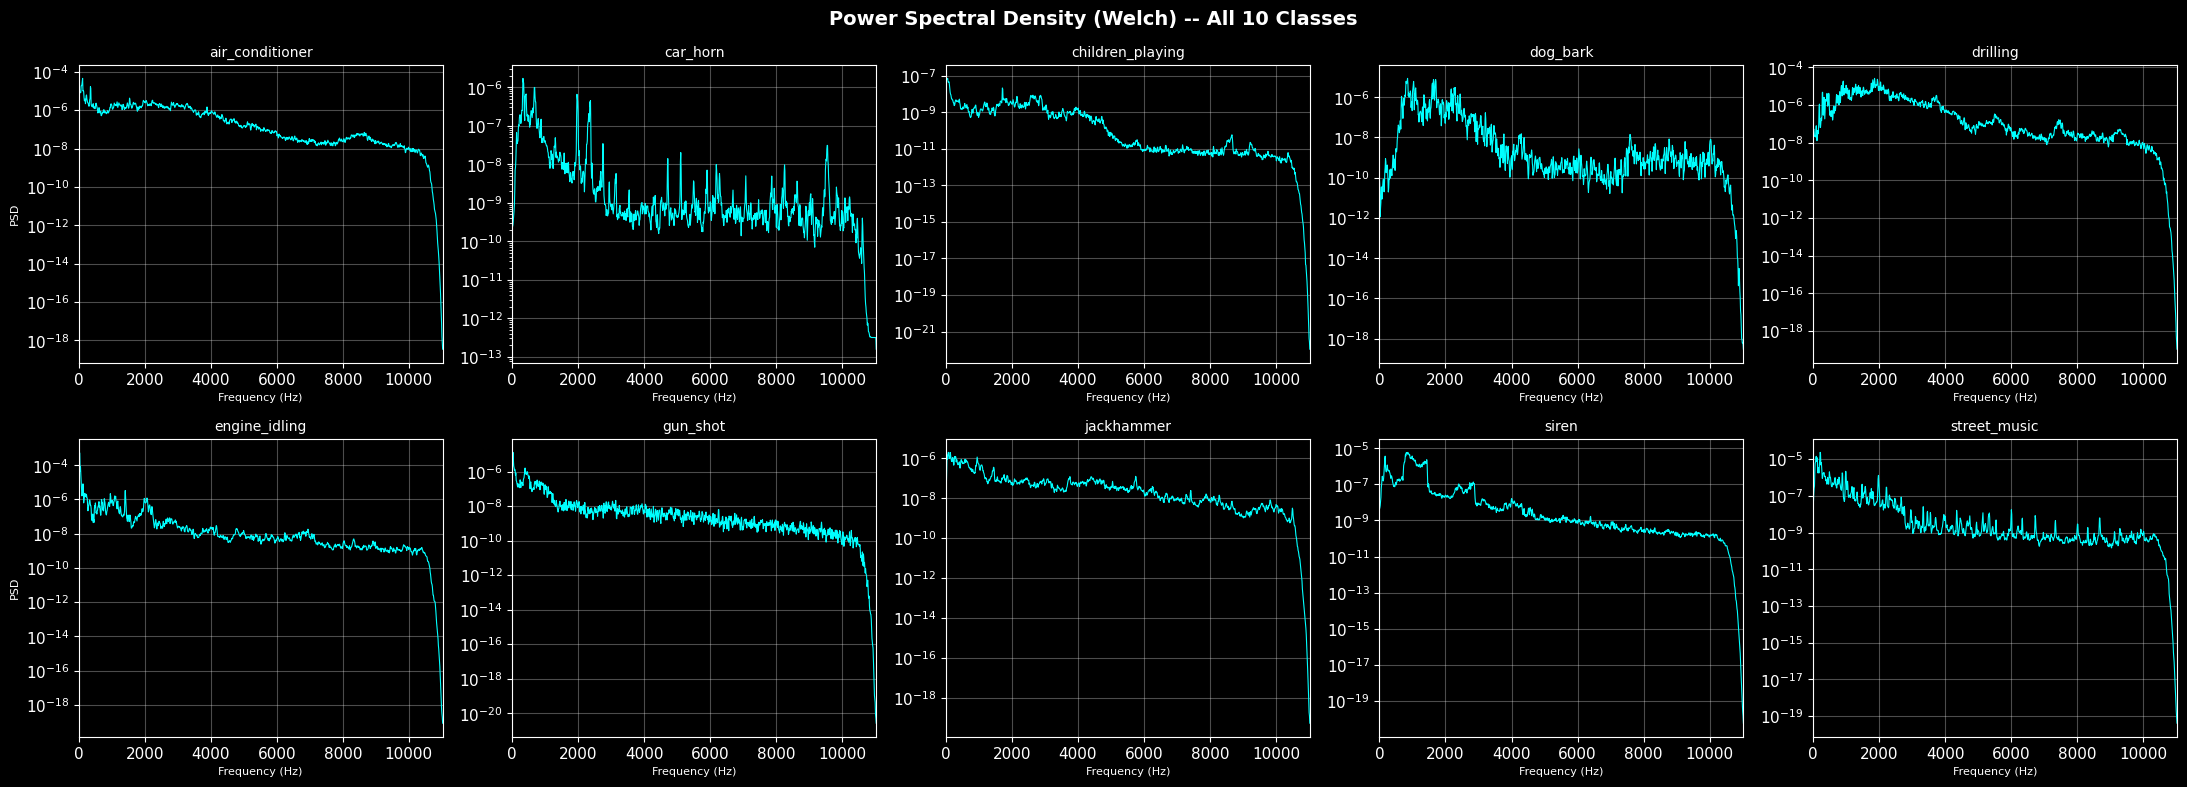

In [50]:
# === 2.1 PSD (Welch) for all 10 classes ===

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Power Spectral Density (Welch) -- All 10 Classes', fontsize=14, fontweight='bold')

psd_data = {}
for idx, cls_name in enumerate(config.CLASS_NAMES):
    ax = axes[idx // 5, idx % 5]
    freqs, psd = compute_psd(samples[cls_name], sr=config.TARGET_SR)
    psd_data[cls_name] = (freqs, psd)
    ax.semilogy(freqs, psd, linewidth=0.8, color='cyan')
    ax.set_title(cls_name, fontsize=10); ax.set_xlim(0, 11025)
    ax.set_xlabel('Frequency (Hz)', fontsize=8)
    if idx % 5 == 0: ax.set_ylabel('PSD', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/fig_psd_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# === 2.2 Dominant Frequencies -- Top 3 per class ===

physical_explanation = {
    'engine_idling': 'Harmonics tan so quay dong co (~1320 RPM)',
    'jackhammer': 'Tan so dap bua khi nen',
    'air_conditioner': 'Quat + may nen hoat dong',
    'street_music': 'Nhac cu tan so thap (bass, drums)',
    'car_horn': 'Tan so thiet ke coi xe',
    'dog_bark': 'Cong huong thanh quan cho',
    'siren': 'Thiet ke cho tai nguoi nghe ro (1-4 kHz)',
    'drilling': 'Tan so quay mui khoan toc do cao',
    'children_playing': 'Background noise tan so thap',
    'gun_shot': 'Broadband impulse, dominant o DC/rat thap',
}

print("=" * 100)
print("DOMINANT FREQUENCIES (Top 3 from PSD)")
print("=" * 100)
print(f"{'Class':20s} {'Top 1':>8s} {'Top 2':>8s} {'Top 3':>8s}  {'Physical Explanation'}")
print("-" * 100)

dom_freq_data = []
for cls_name in config.CLASS_NAMES:
    freqs, psd = psd_data[cls_name]
    top_freqs = find_dominant_frequencies(freqs, psd, n_peaks=3)
    f1, f2, f3 = top_freqs[0][0], top_freqs[1][0], top_freqs[2][0]
    dom_freq_data.append({'Class': cls_name, 'f1': f1, 'f2': f2, 'f3': f3})
    print(f"{cls_name:20s} {f1:7.0f}Hz {f2:7.0f}Hz {f3:7.0f}Hz  {physical_explanation[cls_name]}")

print("-" * 100)
print("Key Insight: Each class has unique frequency fingerprint -> MFCC is suitable feature")

DOMINANT FREQUENCIES (Top 3 from PSD)
Class                   Top 1    Top 2    Top 3  Physical Explanation
----------------------------------------------------------------------------------------------------
air_conditioner          118Hz     108Hz      97Hz  Quat + may nen hoat dong
car_horn                 323Hz     334Hz     345Hz  Tan so thiet ke coi xe
children_playing          54Hz      22Hz      43Hz  Background noise tan so thap
dog_bark                 851Hz    1637Hz    1701Hz  Cong huong thanh quan cho
drilling                1863Hz    1949Hz    1809Hz  Tan so quay mui khoan toc do cao
engine_idling             22Hz      32Hz      54Hz  Harmonics tan so quay dong co (~1320 RPM)
gun_shot                  22Hz      32Hz      11Hz  Broadband impulse, dominant o DC/rat thap
jackhammer                75Hz     129Hz     140Hz  Tan so dap bua khi nen
siren                    861Hz     829Hz     807Hz  Thiet ke cho tai nguoi nghe ro (1-4 kHz)
street_music             215Hz     226H

In [52]:
# === 2.3 Bandwidth Analysis -- 90% Energy ===

print("=" * 100)
print("BANDWIDTH ANALYSIS")
print("=" * 100)

bw_results = []
for cls_name in config.CLASS_NAMES:
    freqs, psd = psd_data[cls_name]
    f_low_90, f_high_90 = compute_bandwidth(freqs, psd, threshold=0.90)
    f_low_95, f_high_95 = compute_bandwidth(freqs, psd, threshold=0.95)
    f_low_99, f_high_99 = compute_bandwidth(freqs, psd, threshold=0.99)

    total = np.sum(psd)
    cumulative = np.cumsum(psd) / total
    idx_999 = np.searchsorted(cumulative, 0.999)
    f_high_999 = float(freqs[min(idx_999, len(freqs) - 1)])

    bw_90 = f_high_90 - f_low_90
    bw_type = 'Narrowband' if bw_90 < 1500 else ('Broadband' if bw_90 > 4000 else 'Medium')

    bw_results.append({
        'Class': cls_name,
        'f_low_90': f_low_90, 'f_high_90': f_high_90, 'BW_90': bw_90,
        'f_high_95': f_high_95, 'f_high_99': f_high_99, 'f_high_999': f_high_999,
        'Type': bw_type,
    })

df_bw = pd.DataFrame(bw_results).sort_values('BW_90').reset_index(drop=True)

print(f"\n{'Class':20s} {'f_low':>8s} {'f_high':>8s} {'BW (90%)':>10s} {'Type':>12s}")
print("-" * 70)
for _, row in df_bw.iterrows():
    print(f"{row['Class']:20s} {row['f_low_90']:7.0f}Hz {row['f_high_90']:7.0f}Hz "
          f"{row['BW_90']:9.0f}Hz {row['Type']:>12s}")

print(f"\n{'Class':20s} {'f_high 90%':>12s} {'f_high 95%':>12s} {'f_high 99%':>12s} {'f_high 99.9%':>14s}")
print("-" * 80)
for _, row in df_bw.iterrows():
    print(f"{row['Class']:20s} {row['f_high_90']:11.0f}Hz {row['f_high_95']:11.0f}Hz "
          f"{row['f_high_99']:11.0f}Hz {row['f_high_999']:13.0f}Hz")

max_f999 = df_bw['f_high_999'].max()
max_class = df_bw.loc[df_bw['f_high_999'].idxmax(), 'Class']
print(f"\n>>> f_max(99.9%) = {max_f999:.0f} Hz ({max_class})")
print(f">>> Nyquist: sr >= 2 x {max_f999:.0f} = {2*max_f999:.0f} Hz")
print(f">>> Chosen: TARGET_SR = {config.TARGET_SR} Hz")

BANDWIDTH ANALYSIS

Class                   f_low   f_high   BW (90%)         Type
----------------------------------------------------------------------
engine_idling             22Hz     614Hz       592Hz   Narrowband
siren                    183Hz    1432Hz      1249Hz   Narrowband
gun_shot                  11Hz    1270Hz      1260Hz   Narrowband
street_music              75Hz    1518Hz      1443Hz   Narrowband
dog_bark                 797Hz    2401Hz      1604Hz       Medium
car_horn                 258Hz    2369Hz      2110Hz       Medium
drilling                 764Hz    3725Hz      2961Hz       Medium
children_playing          22Hz    3736Hz      3714Hz       Medium
air_conditioner           54Hz    4167Hz      4113Hz    Broadband
jackhammer                65Hz    5469Hz      5405Hz    Broadband

Class                  f_high 90%   f_high 95%   f_high 99%   f_high 99.9%
--------------------------------------------------------------------------------
engine_idling                

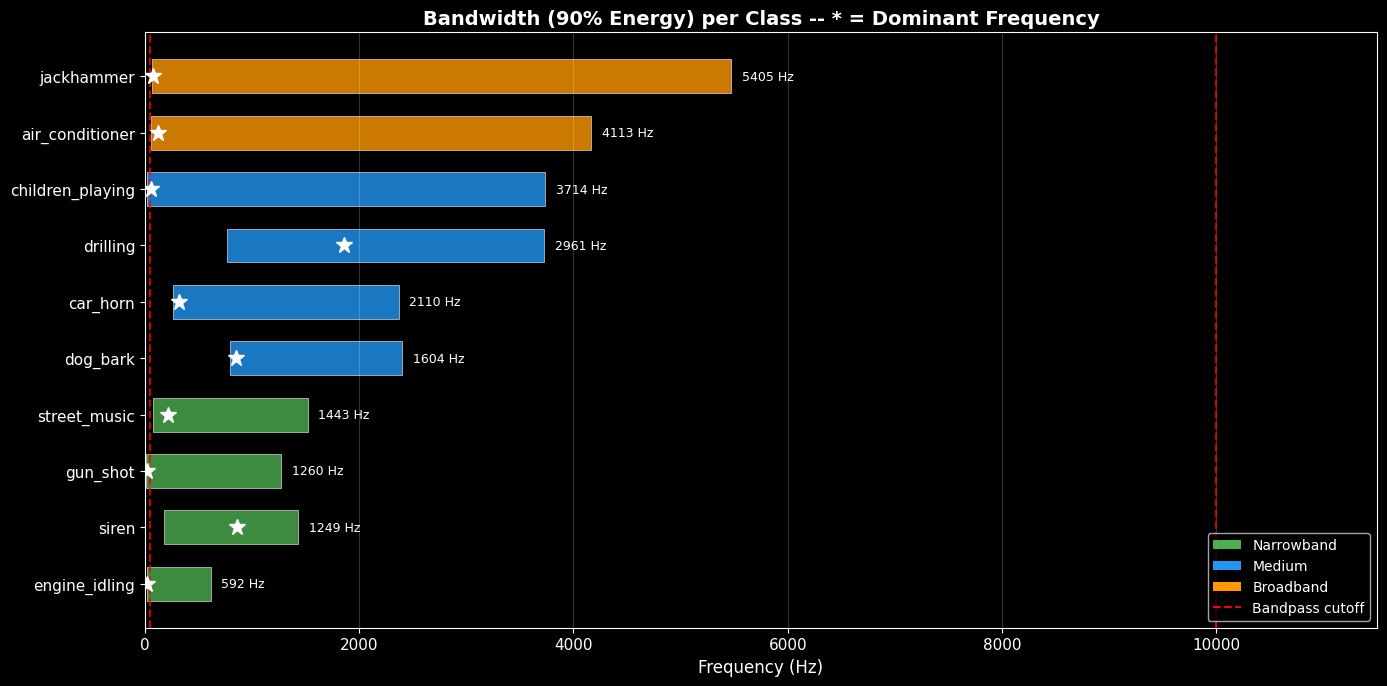

In [53]:
# === 2.4 Bandwidth horizontal bar chart ===

fig, ax = plt.subplots(figsize=(14, 7))
colors_bw = {'Narrowband': '#4CAF50', 'Medium': '#2196F3', 'Broadband': '#FF9800'}

for i, (_, row) in enumerate(df_bw.iterrows()):
    color = colors_bw[row['Type']]
    ax.barh(i, row['BW_90'], left=row['f_low_90'], height=0.6, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    dom_f = [r for r in dom_freq_data if r['Class'] == row['Class']][0]['f1']
    ax.plot(dom_f, i, 'w*', markersize=12, zorder=5)
    ax.text(row['f_high_90'] + 100, i, f"{row['BW_90']:.0f} Hz", va='center', fontsize=9, color='white')

ax.set_yticks(range(len(df_bw))); ax.set_yticklabels(df_bw['Class'])
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_title('Bandwidth (90% Energy) per Class -- * = Dominant Frequency', fontsize=14, fontweight='bold')
ax.axvline(x=config.FILTER_LOW_FREQ, color='red', linestyle='--', alpha=0.8, label=f'Filter low = {config.FILTER_LOW_FREQ} Hz')
ax.axvline(x=config.FILTER_HIGH_FREQ, color='red', linestyle='--', alpha=0.8, label=f'Filter high = {config.FILTER_HIGH_FREQ} Hz')
ax.set_xlim(0, 11500)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors_bw.items()]
legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label='Bandpass cutoff'))
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('results/figures/fig_bandwidth_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

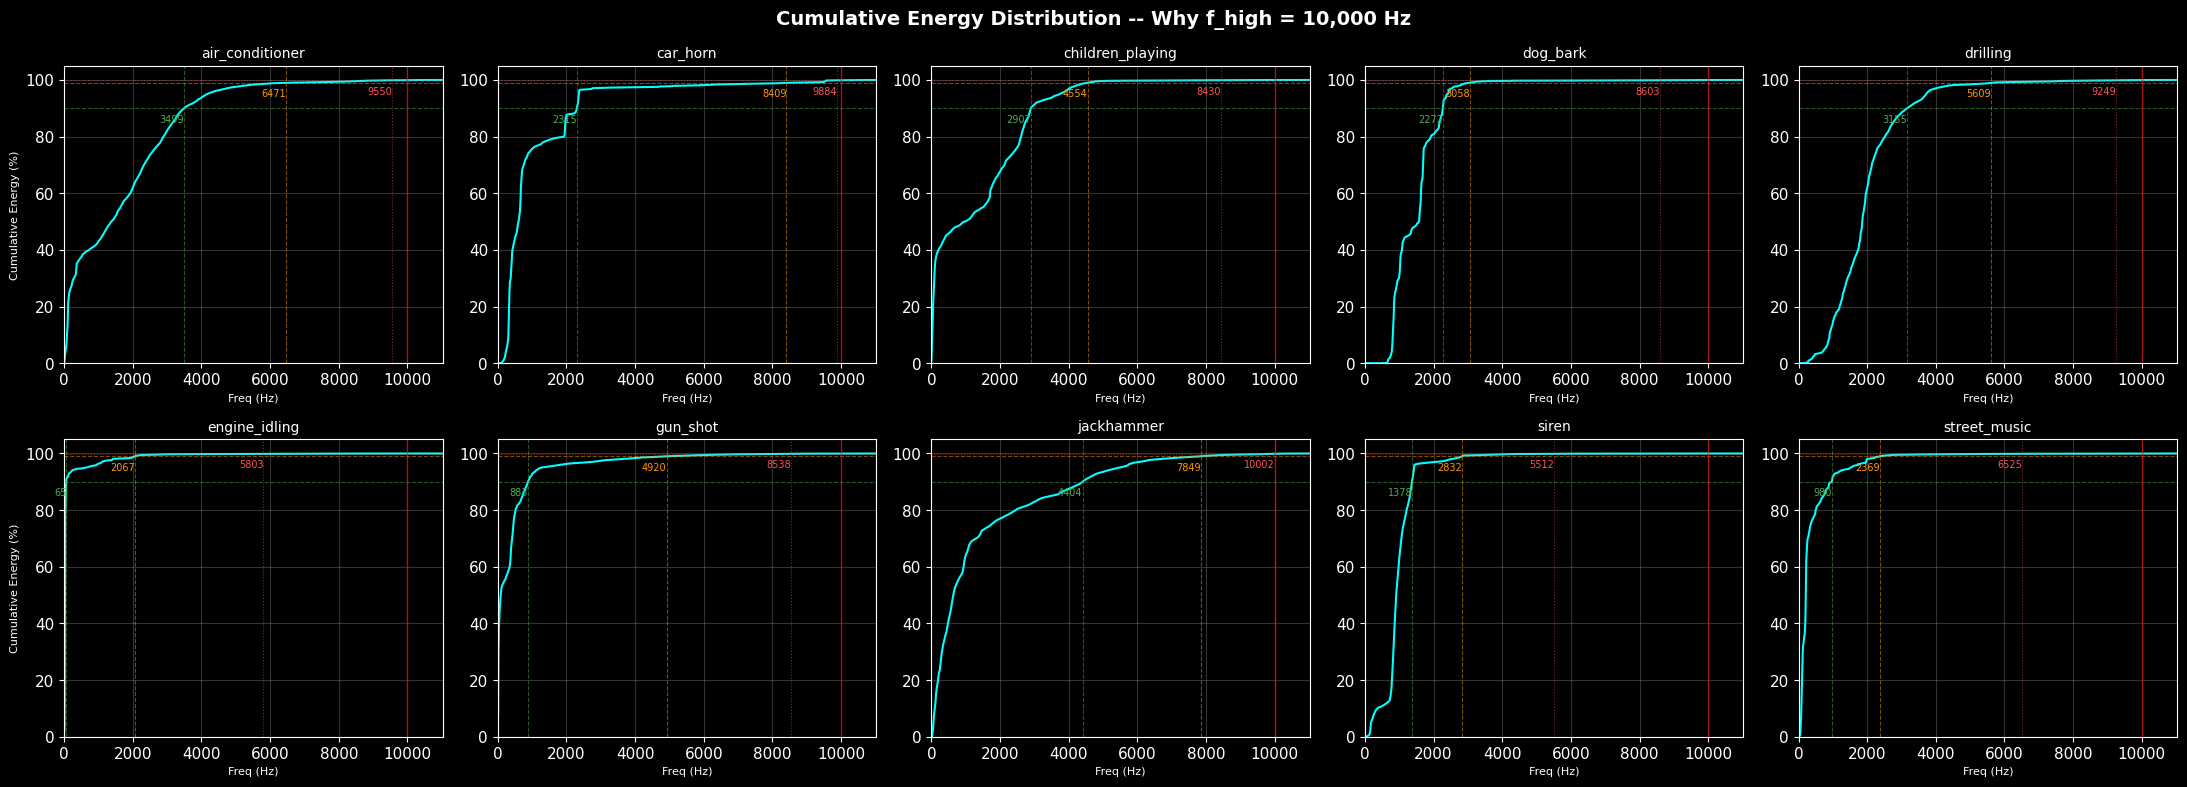

Green=90%, Orange=99%, Red dot=99.9%, Red solid=f_high=10,000 Hz


In [54]:
# === 2.5 Cumulative Energy -- Why f_high = 10,000 Hz ===

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Cumulative Energy Distribution -- Why f_high = 10,000 Hz', fontsize=14, fontweight='bold')

for idx, cls_name in enumerate(config.CLASS_NAMES):
    ax = axes[idx // 5, idx % 5]
    freqs, psd = psd_data[cls_name]
    total = np.sum(psd)
    cumulative = np.cumsum(psd) / total * 100
    ax.plot(freqs, cumulative, color='cyan', linewidth=1.5)
    ax.set_title(cls_name, fontsize=10); ax.set_xlim(0, 11025); ax.set_ylim(0, 105)

    for thresh, ct, ls in [(90, '#4CAF50', '--'), (99, '#FF9800', '--'), (99.9, '#FF5252', ':')]:
        idx_t = np.searchsorted(cumulative, thresh)
        if idx_t < len(freqs):
            f_t = freqs[idx_t]
            ax.axhline(y=thresh, color=ct, linestyle=ls, alpha=0.5, linewidth=0.8)
            ax.axvline(x=f_t, color=ct, linestyle=ls, alpha=0.5, linewidth=0.8)
            ax.text(f_t, thresh - 5, f'{f_t:.0f}', fontsize=7, color=ct, ha='right')

    ax.axvline(x=10000, color='red', linestyle='-', alpha=0.6, linewidth=1)
    ax.set_xlabel('Freq (Hz)', fontsize=8)
    if idx % 5 == 0: ax.set_ylabel('Cumulative Energy (%)', fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('results/figures/fig_cumulative_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Green=90%, Orange=99%, Red dot=99.9%, Red solid=f_high=10,000 Hz")

In [55]:
# === 2.6 DWT Energy Distribution ===

print("=" * 100)
print("DWT ENERGY DISTRIBUTION (db4, 8 levels)")
print("=" * 100)

dwt_results = {}
for cls_name in config.CLASS_NAMES:
    dwt_results[cls_name] = compute_dwt_energy(samples[cls_name], sr=config.TARGET_SR)

print(f"\n{'Class':20s} {'Top Band':>10s} {'Freq Range':>20s} {'Energy %':>10s}")
print("-" * 70)
for cls_name in config.CLASS_NAMES:
    top = max(dwt_results[cls_name], key=lambda b: b['energy_ratio'])
    f_lo, f_hi = top['freq_range']
    print(f"{cls_name:20s} {top['level']:>10s} {f_lo:8.0f}-{f_hi:.0f} Hz {top['energy_ratio']*100:9.1f}%")

DWT ENERGY DISTRIBUTION (db4, 8 levels)

Class                  Top Band           Freq Range   Energy %
----------------------------------------------------------------------
air_conditioner              D3     2756-5512 Hz      26.8%
car_horn                     D5      689-1378 Hz      36.5%
children_playing             D3     2756-5512 Hz      26.8%
dog_bark                     D3     2756-5512 Hz      46.6%
drilling                     D3     2756-5512 Hz      51.5%
engine_idling                A8        0-86 Hz      78.9%
gun_shot                     A8        0-86 Hz      35.7%
jackhammer                   D4     1378-2756 Hz      19.4%
siren                        D4     1378-2756 Hz      60.6%
street_music                 D6      345-689 Hz      33.4%


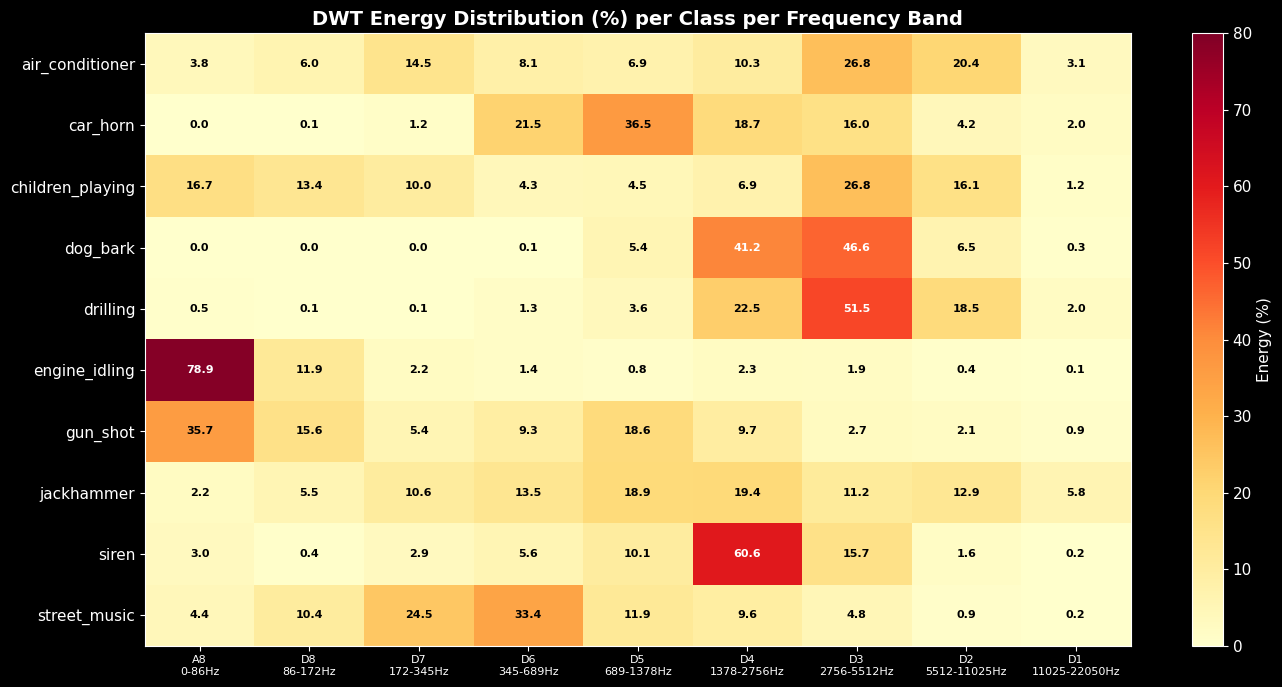

In [56]:
# === 2.7 DWT Energy heatmap ===

all_bands = [b['level'] for b in dwt_results[config.CLASS_NAMES[0]]]
band_labels = []
for b in dwt_results[config.CLASS_NAMES[0]]:
    f_lo, f_hi = b['freq_range']
    band_labels.append(f"{b['level']}\n{f_lo:.0f}-{f_hi:.0f}Hz")

energy_matrix = np.zeros((len(config.CLASS_NAMES), len(all_bands)))
for i, cls_name in enumerate(config.CLASS_NAMES):
    for j, band in enumerate(dwt_results[cls_name]):
        energy_matrix[i, j] = band['energy_ratio'] * 100

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(energy_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=80)
ax.set_xticks(range(len(band_labels))); ax.set_xticklabels(band_labels, fontsize=8)
ax.set_yticks(range(len(config.CLASS_NAMES))); ax.set_yticklabels(config.CLASS_NAMES)
ax.set_title('DWT Energy Distribution (%) per Class per Frequency Band', fontsize=14, fontweight='bold')

for i in range(len(config.CLASS_NAMES)):
    for j in range(len(all_bands)):
        val = energy_matrix[i, j]
        color = 'white' if val > 40 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Energy (%)')
plt.tight_layout()
plt.savefig('results/figures/fig_dwt_energy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

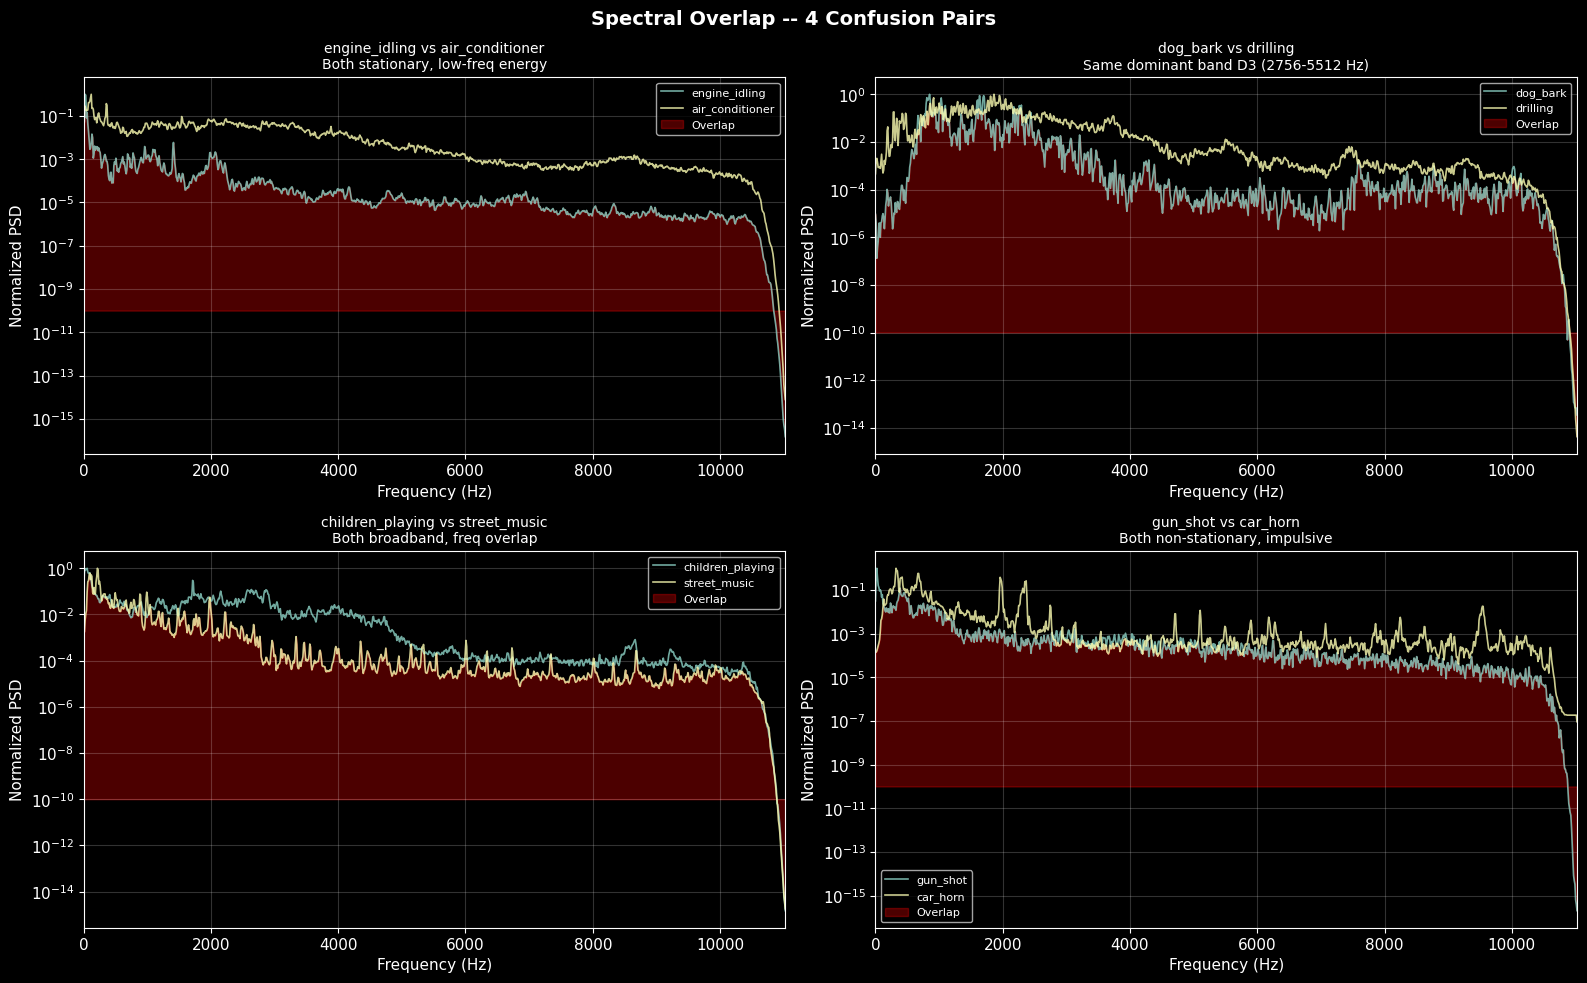

Red shaded = spectral overlap -> confusion source in classification


In [57]:
# === 2.8 Spectral Overlap -- 4 Confusion Pairs ===

confusion_pairs = [
    ('engine_idling', 'air_conditioner', 'Both stationary, low-freq energy'),
    ('dog_bark', 'drilling', 'Same dominant band D3 (2756-5512 Hz)'),
    ('children_playing', 'street_music', 'Both broadband, freq overlap'),
    ('gun_shot', 'car_horn', 'Both non-stationary, impulsive'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Spectral Overlap -- 4 Confusion Pairs', fontsize=14, fontweight='bold')

for idx, (cls_a, cls_b, reason) in enumerate(confusion_pairs):
    ax = axes[idx // 2, idx % 2]
    freqs_a, psd_a = psd_data[cls_a]
    freqs_b, psd_b = psd_data[cls_b]
    psd_a_norm = psd_a / np.max(psd_a)
    psd_b_norm = psd_b / np.max(psd_b)

    ax.semilogy(freqs_a, psd_a_norm, label=cls_a, alpha=0.8, linewidth=1.2)
    ax.semilogy(freqs_b, psd_b_norm, label=cls_b, alpha=0.8, linewidth=1.2)
    overlap = np.minimum(psd_a_norm, psd_b_norm)
    ax.fill_between(freqs_a, 1e-10, overlap, alpha=0.3, color='red', label='Overlap')
    ax.set_title(f'{cls_a} vs {cls_b}\n{reason}', fontsize=10)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Normalized PSD')
    ax.set_xlim(0, 11025); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('results/figures/fig_spectral_overlap_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Red shaded = spectral overlap -> confusion source in classification")

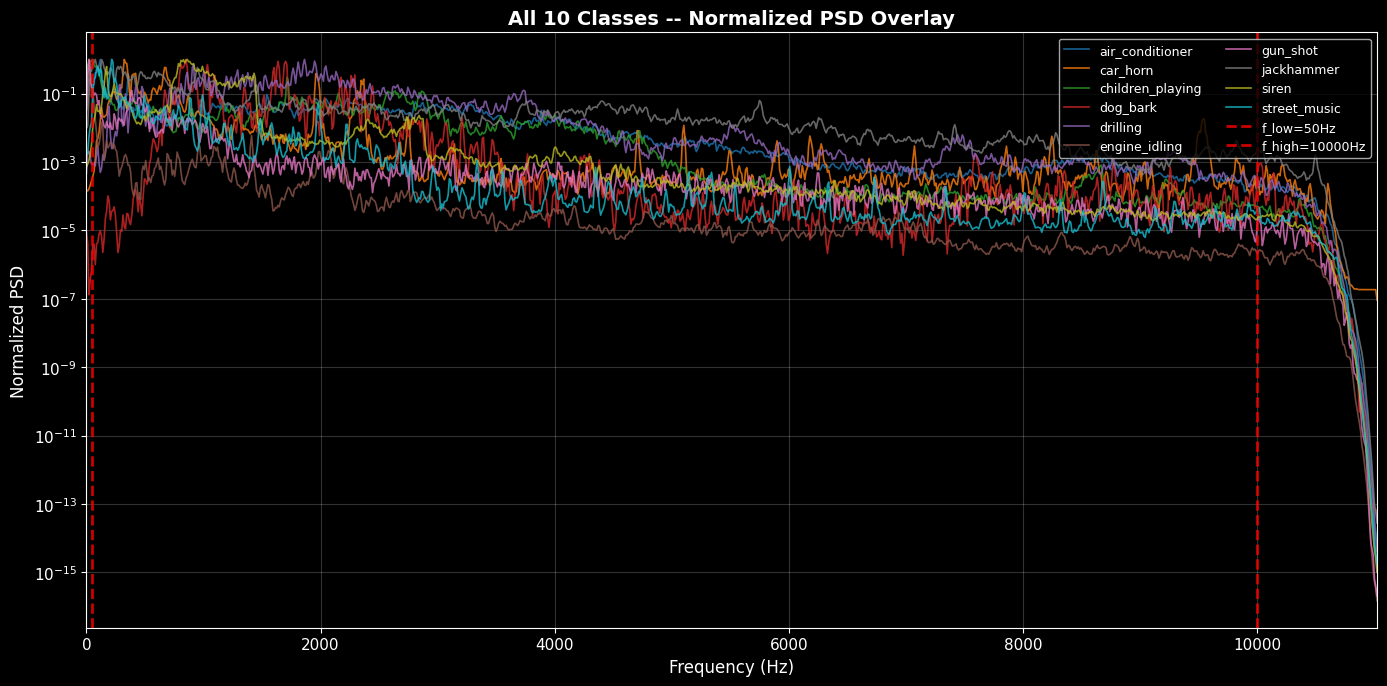

In [58]:
# === 2.9 Overlay all PSD ===

fig, ax = plt.subplots(figsize=(14, 7))
colors_cls = plt.cm.tab10(np.linspace(0, 1, 10))
for idx, cls_name in enumerate(config.CLASS_NAMES):
    freqs, psd = psd_data[cls_name]
    ax.semilogy(freqs, psd / np.max(psd), label=cls_name, color=colors_cls[idx], linewidth=1.2, alpha=0.8)

ax.axvline(x=config.FILTER_LOW_FREQ, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'f_low={config.FILTER_LOW_FREQ}Hz')
ax.axvline(x=config.FILTER_HIGH_FREQ, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'f_high={config.FILTER_HIGH_FREQ}Hz')
ax.set_xlabel('Frequency (Hz)', fontsize=12); ax.set_ylabel('Normalized PSD', fontsize=12)
ax.set_title('All 10 Classes -- Normalized PSD Overlay', fontsize=14, fontweight='bold')
ax.set_xlim(0, 11025); ax.legend(fontsize=9, ncol=2, loc='upper right'); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('results/figures/fig_psd_overlay_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 3: Noise Sources

Phan tich cac loai noise trong dataset va danh gia DSP co the giup gi.

In [59]:
# === 3.1 SNR Estimation for all 10 classes ===

print("=" * 90)
print("PART 3: Noise Sources -- SNR Estimation")
print("=" * 90)
print("Method: Frame-based (25ms frames, 10th percentile power = noise floor)")
print("SNR (dB) = 10 * log10(P_signal / P_noise)")
print()

snr_results = []
for cls_name in config.CLASS_NAMES:
    snr = estimate_snr(samples[cls_name], sr=config.TARGET_SR)
    snr_results.append({'Class': cls_name, 'SNR_dB': snr})

df_snr = pd.DataFrame(snr_results).sort_values('SNR_dB').reset_index(drop=True)

print(f"{'Class':20s} {'SNR (dB)':>10s}  {'Interpretation'}")
print("-" * 80)
for _, row in df_snr.iterrows():
    snr = row['SNR_dB']
    if snr == float('inf'):
        interp, snr_str = 'Silent frames exist (P_noise ~ 0)', 'inf'
    elif snr < 3:
        interp, snr_str = 'Very low -- signal ~ noise', f'{snr:.1f}'
    elif snr < 6:
        interp, snr_str = 'Low -- significant noise', f'{snr:.1f}'
    elif snr < 20:
        interp, snr_str = 'Medium -- clear signal', f'{snr:.1f}'
    else:
        interp, snr_str = 'High -- very clear, minimal noise', f'{snr:.1f}'
    print(f"{row['Class']:20s} {snr_str:>10s}  {interp}")

PART 3: Noise Sources -- SNR Estimation
Method: Frame-based (25ms frames, 10th percentile power = noise floor)
SNR (dB) = 10 * log10(P_signal / P_noise)

Class                  SNR (dB)  Interpretation
--------------------------------------------------------------------------------
air_conditioner             2.0  Very low -- signal ~ noise
engine_idling               2.9  Very low -- signal ~ noise
siren                       3.4  Low -- significant noise
jackhammer                  3.8  Low -- significant noise
children_playing            4.9  Low -- significant noise
street_music                5.8  Low -- significant noise
drilling                   24.6  High -- very clear, minimal noise
car_horn                    inf  Silent frames exist (P_noise ~ 0)
gun_shot                    inf  Silent frames exist (P_noise ~ 0)
dog_bark                    inf  Silent frames exist (P_noise ~ 0)


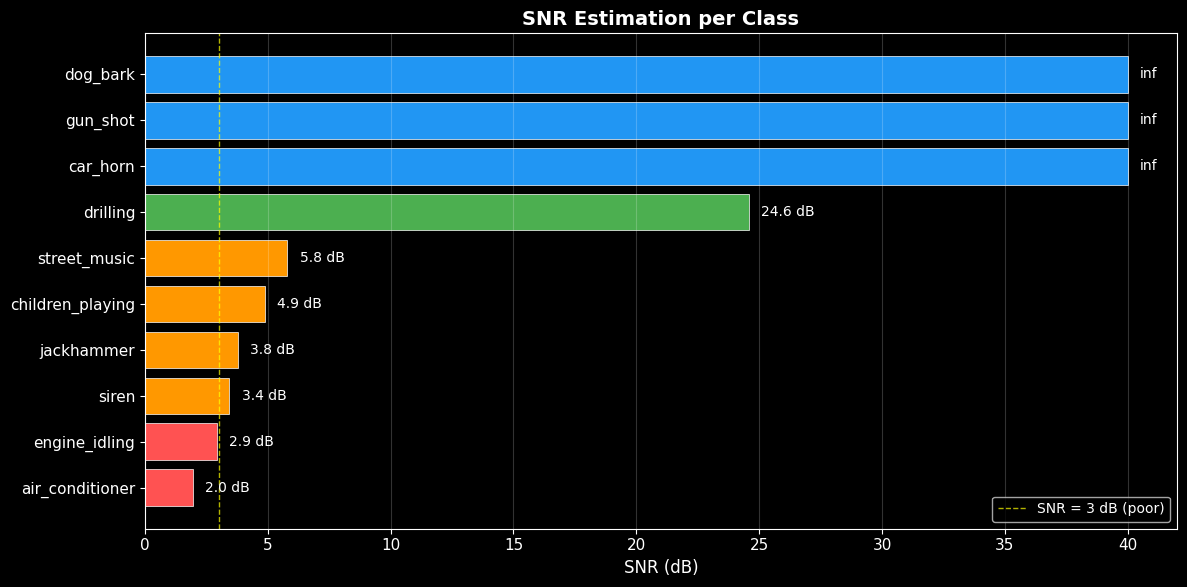

In [60]:
# === 3.2 SNR bar chart ===

fig, ax = plt.subplots(figsize=(12, 6))
snr_display = [min(row['SNR_dB'], 40) for _, row in df_snr.iterrows()]
colors_snr = ['#FF5252' if s < 3 else '#FF9800' if s < 6 else '#4CAF50' if s < 30 else '#2196F3' for s in snr_display]

ax.barh(range(len(df_snr)), snr_display, color=colors_snr, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_snr))); ax.set_yticklabels(df_snr['Class'])
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_title('SNR Estimation per Class', fontsize=14, fontweight='bold')

for i, (_, row) in enumerate(df_snr.iterrows()):
    snr = row['SNR_dB']
    label = 'inf' if snr == float('inf') else f'{snr:.1f} dB'
    ax.text(snr_display[i] + 0.5, i, label, va='center', fontsize=10, color='white')

ax.axvline(x=3, color='yellow', linestyle='--', alpha=0.7, linewidth=1, label='SNR = 3 dB (poor)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('results/figures/fig_snr_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# === 3.3 Noise Type Analysis ===

print("=" * 90)
print("NOISE TYPE ANALYSIS")
print("=" * 90)

noise_analysis = []
for cls_name in config.CLASS_NAMES:
    y = samples[cls_name]
    freqs, psd = psd_data[cls_name]
    total_power = np.sum(psd)

    dc_power = np.sum(psd[freqs < 50]) / total_power * 100
    hf_power = np.sum(psd[freqs > 10000]) / total_power * 100

    low_mask = (freqs >= 50) & (freqs < 1000)
    high_mask = (freqs >= 1000) & (freqs <= 10000)
    lp = np.sum(psd[low_mask]); hp = np.sum(psd[high_mask])
    tilt = 10 * np.log10(lp / hp) if hp > 0 else float('inf')

    noise_analysis.append({
        'Class': cls_name, 'DC_offset': abs(np.mean(y)),
        'Energy_below_50Hz': dc_power, 'Energy_above_10kHz': hf_power,
        'Spectral_tilt_dB': tilt,
    })

df_noise = pd.DataFrame(noise_analysis)

print(f"\n{'Class':20s} {'DC offset':>10s} {'<50Hz (%)':>10s} {'>10kHz (%)':>12s} {'Tilt (dB)':>10s}")
print("-" * 75)
for _, row in df_noise.iterrows():
    tilt = f"{row['Spectral_tilt_dB']:.1f}" if row['Spectral_tilt_dB'] != float('inf') else 'inf'
    print(f"{row['Class']:20s} {row['DC_offset']:10.6f} {row['Energy_below_50Hz']:9.2f}% "
          f"{row['Energy_above_10kHz']:11.2f}% {tilt:>10s}")

print("\nDC offset: mean(y) != 0 -> Bandpass removes")
print("Energy <50Hz: Mechanical vibration -> Bandpass (f_low=50) removes")
print("Energy >10kHz: Electronic noise -> Bandpass (f_high=10k) removes")
print("Spectral tilt: positive = low-freq dominant -> Pre-emphasis compensates")

NOISE TYPE ANALYSIS

Class                 DC offset  <50Hz (%)   >10kHz (%)  Tilt (dB)
---------------------------------------------------------------------------
air_conditioner        0.000848      4.39%        0.04%       -1.7
car_horn               0.000002      0.01%        0.09%        4.9
children_playing       0.000067     16.33%        0.01%       -1.7
dog_bark               0.000000      0.00%        0.03%       -3.7
drilling               0.000461      0.01%        0.01%       -8.0
engine_idling          0.000205     83.04%        0.00%        5.6
gun_shot               0.001543     41.32%        0.01%        8.3
jackhammer             0.000097      2.13%        0.10%        2.3
siren                  0.000055      0.02%        0.00%        2.1
street_music           0.000012      0.35%        0.01%       10.2

DC offset: mean(y) != 0 -> Bandpass removes
Energy <50Hz: Mechanical vibration -> Bandpass (f_low=50) removes
Energy >10kHz: Electronic noise -> Bandpass (f_high=10k

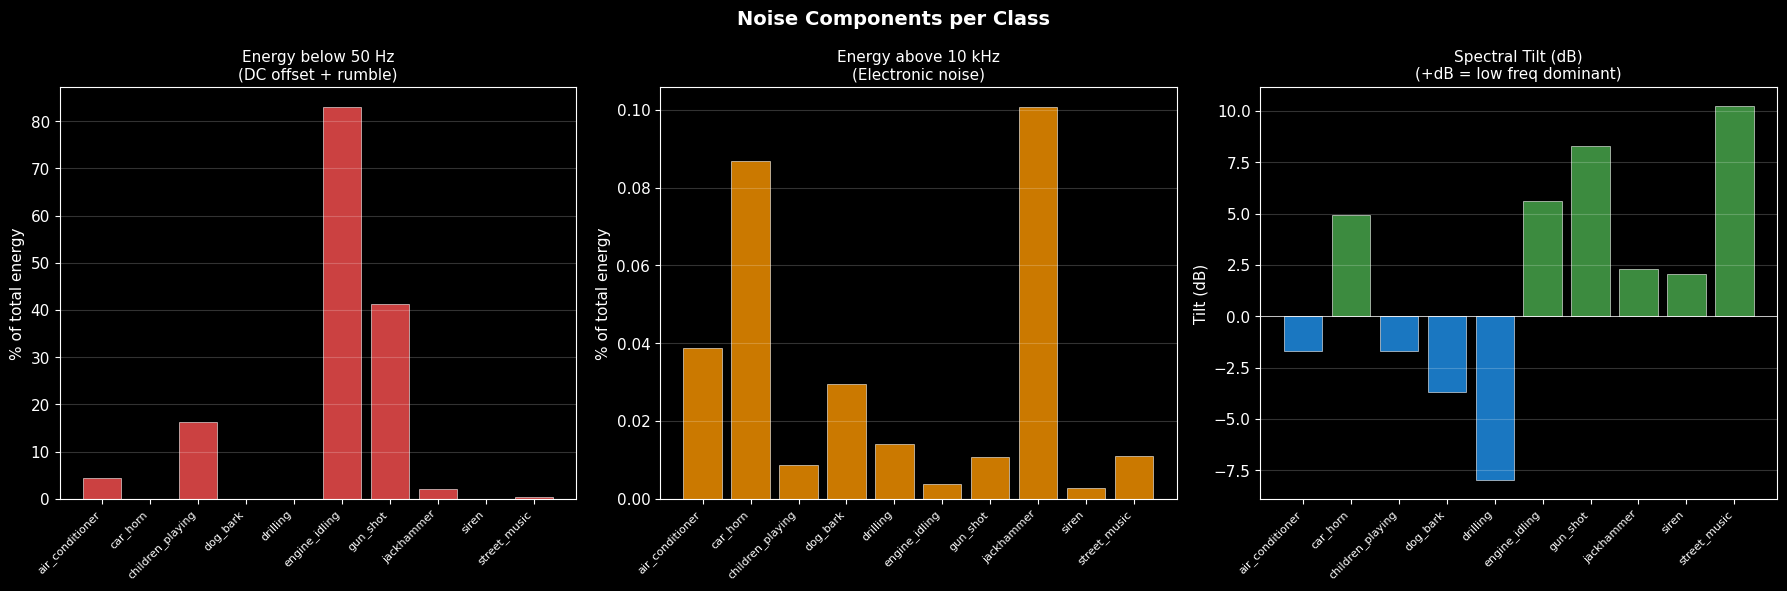

In [62]:
# === 3.4 Noise components visualization ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Noise Components per Class', fontsize=14, fontweight='bold')
classes = df_noise['Class'].tolist()
x = range(len(classes))

ax = axes[0]
ax.bar(x, df_noise['Energy_below_50Hz'].values, color='#FF5252', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_title('Energy below 50 Hz\n(DC offset + rumble)', fontsize=11)
ax.set_ylabel('% of total energy'); ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8); ax.grid(True, alpha=0.2, axis='y')

ax = axes[1]
ax.bar(x, df_noise['Energy_above_10kHz'].values, color='#FF9800', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_title('Energy above 10 kHz\n(Electronic noise)', fontsize=11)
ax.set_ylabel('% of total energy'); ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8); ax.grid(True, alpha=0.2, axis='y')

ax = axes[2]
vals = [min(v, 30) for v in df_noise['Spectral_tilt_dB'].values]
colors_tilt = ['#4CAF50' if v > 0 else '#2196F3' for v in vals]
ax.bar(x, vals, color=colors_tilt, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_title('Spectral Tilt (dB)\n(+dB = low freq dominant)', fontsize=11)
ax.set_ylabel('Tilt (dB)'); ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax.axhline(y=0, color='white', linewidth=0.5); ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('results/figures/fig_noise_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# === 3.5 DSP Before/After ===

from src.dsp_pipeline import apply_dsp_pipeline

demo_classes = ['air_conditioner', 'gun_shot']
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('DSP Pipeline Effect: Before vs After', fontsize=14, fontweight='bold')

for i, cls_name in enumerate(demo_classes):
    y_raw = samples[cls_name]
    y_dsp = apply_dsp_pipeline(y_raw, sr=config.TARGET_SR)
    t = np.arange(len(y_raw)) / config.TARGET_SR

    ax = axes[i, 0]
    ax.plot(t, y_raw, color='#FF5252', linewidth=0.3, alpha=0.7, label='Raw')
    ax.plot(t, y_dsp, color='#4CAF50', linewidth=0.3, alpha=0.7, label='DSP')
    ax.set_title(f'{cls_name} -- Waveform', fontsize=10)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude'); ax.legend(fontsize=8)

    ax = axes[i, 1]
    fr, pr = compute_psd(y_raw); fd, pd_ = compute_psd(y_dsp)
    ax.semilogy(fr, pr, color='#FF5252', linewidth=1, alpha=0.7, label='Raw')
    ax.semilogy(fd, pd_, color='#4CAF50', linewidth=1, alpha=0.7, label='DSP')
    ax.axvline(x=50, color='yellow', linestyle='--', alpha=0.5)
    ax.axvline(x=10000, color='yellow', linestyle='--', alpha=0.5)
    ax.set_title(f'{cls_name} -- PSD', fontsize=10)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD'); ax.legend(fontsize=8)

    ax = axes[i, 2]
    snr_raw = estimate_snr(y_raw); snr_dsp = estimate_snr(y_dsp)
    sv = [snr_raw if snr_raw != float('inf') else 40, snr_dsp if snr_dsp != float('inf') else 40]
    bi = ax.bar(['Raw', 'DSP'], sv, color=['#FF5252', '#4CAF50'], edgecolor='white', linewidth=1)
    ax.set_title(f'{cls_name} -- SNR', fontsize=10); ax.set_ylabel('SNR (dB)')
    for b, val in zip(bi, [snr_raw, snr_dsp]):
        label = 'inf' if val == float('inf') else f'{val:.1f}'
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                label, ha='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/fig_dsp_before_after_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Yellow dashed = bandpass cutoffs (50 Hz, 10,000 Hz)")

ImportError: cannot import name 'apply_dsp_pipeline' from 'src.dsp_pipeline' (d:\MSA-FPT\Digital Signal Processing\workspaces\project\DSP501\src\dsp_pipeline.py)

### Why DSP Did Not Improve Classification

1. **Dataset already clean**: UrbanSound8K is curated
2. **MFCC/Mel = implicit DSP**: FMIN=50, FMAX=10000 already filters like bandpass
3. **ML learns to ignore noise**: RF/SVM find useful features automatically
4. **Bandpass near identity**: 99%+ energy already within 50-10,000 Hz

---
# PART 4: Sampling Requirements

Xac dinh tat ca tham so sampling tu du lieu thuc te.

In [ ]:
# === 4.1 Nyquist Theorem ===

print("=" * 90)
print("PART 4: Sampling Requirements")
print("=" * 90)
print("\n4.1 SAMPLE RATE DERIVATION (Nyquist Theorem)")
print("-" * 60)

print("\nStep 1: Find f_max(99.9%) for each class from PSD:")
f_max_per_class = {}
for cls_name in config.CLASS_NAMES:
    freqs, psd = psd_data[cls_name]
    total = np.sum(psd)
    cumulative = np.cumsum(psd) / total
    idx_999 = np.searchsorted(cumulative, 0.999)
    f_max = float(freqs[min(idx_999, len(freqs) - 1)])
    f_max_per_class[cls_name] = f_max
    print(f"  {cls_name:20s}: f_max(99.9%) = {f_max:8.0f} Hz")

overall_fmax = max(f_max_per_class.values())
fmax_class = max(f_max_per_class, key=f_max_per_class.get)

print(f"\nStep 2: Overall f_max(99.9%) = {overall_fmax:.0f} Hz ({fmax_class})")
print(f"\nStep 3: Nyquist: sr >= 2 * f_max = 2 * {overall_fmax:.0f} = {2*overall_fmax:.0f} Hz")
print(f"\nStep 4: Chosen TARGET_SR = {config.TARGET_SR} Hz")
print(f"         Nyquist = {config.TARGET_SR // 2} Hz > {overall_fmax:.0f} Hz")

print("\nCandidate sample rates:")
for sr_cand in [8000, 16000, 22050, 44100]:
    nyq = sr_cand // 2
    ok = 'OK' if nyq >= overall_fmax else 'FAIL'
    print(f"  sr = {sr_cand:6d} Hz -> Nyquist = {nyq:5d} Hz  [{ok}]")

In [ ]:
# === 4.2 Audio Duration ===

print("4.2 AUDIO DURATION")
print("-" * 60)
print(f"Duration  = {config.AUDIO_DURATION} seconds")
print(f"N_SAMPLES = {config.TARGET_SR} * {config.AUDIO_DURATION} = {config.N_SAMPLES}")
print(f"RAM per clip = {config.N_SAMPLES * 4 / 1024:.1f} KB (float32)")
print(f"Total dataset = {config.N_SAMPLES * 4 * 8732 / 1024**3:.2f} GB")

durations = []
for cls_name in config.CLASS_NAMES:
    subset = metadata[metadata['class'] == cls_name]
    for _, row in subset.head(5).iterrows():
        fp = get_file_path(row)
        if os.path.exists(fp):
            dur = librosa.get_duration(filename=fp)
            durations.append(dur)

print(f"\nActual clip durations (sampled {len(durations)} clips):")
print(f"  Min: {min(durations):.2f}s, Max: {max(durations):.2f}s, Mean: {np.mean(durations):.2f}s")
print(f"  Clips <= 4s: {sum(1 for d in durations if d <= 4.0)}/{len(durations)}")

In [ ]:
# === 4.3 Window Size Comparison ===

print("4.3 WINDOW SIZE -- Time-Frequency Resolution Trade-off")
print("-" * 60)
sr = config.TARGET_SR
window_sizes = [512, 1024, 2048, 4096]

print(f"{'N_FFT':>6s} {'dt (ms)':>10s} {'df (Hz)':>10s} {'Frames':>8s}")
print("-" * 50)
for nfft in window_sizes:
    dt = nfft / sr * 1000; df = sr / nfft
    hop = nfft // 4; n_frames = (config.N_SAMPLES - nfft) // hop + 1
    marker = ' <-- CHOSEN' if nfft == config.N_FFT else ''
    print(f"{nfft:6d} {dt:9.1f}ms {df:9.1f}Hz {n_frames:8d} {marker}")

print(f"\nChosen: N_FFT = {config.N_FFT}")
print(f"  df = {sr/config.N_FFT:.1f} Hz -> distinguishes engine(22Hz) vs jackhammer(75Hz)")
print(f"  dt = {config.N_FFT/sr*1000:.1f} ms -> captures gun_shot, dog_bark transients")

In [ ]:
# === 4.4 Window size comparison on siren ===

y_siren = samples['siren']; sr = config.TARGET_SR
window_sizes = [512, 1024, 2048, 4096]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Window Size Comparison on "siren"', fontsize=14, fontweight='bold')

for i, nfft in enumerate(window_sizes):
    ax = axes[i]; hop = nfft // 4
    S = librosa.stft(y_siren, n_fft=nfft, hop_length=hop, win_length=nfft)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=hop, x_axis='time', y_axis='hz', ax=ax, cmap='magma')
    dt = nfft / sr * 1000; df_val = sr / nfft
    chosen = ' [CHOSEN]' if nfft == config.N_FFT else ''
    ax.set_title(f'N_FFT={nfft}{chosen}\ndt={dt:.0f}ms, df={df_val:.1f}Hz', fontsize=10)
    ax.set_ylim(0, 5000)
    if i > 0: ax.set_ylabel('')

plt.tight_layout()
plt.savefig('results/figures/fig_window_size_comparison_siren.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === 4.5 Spectral Leakage Comparison -- Why Hann? ===

y_engine = samples['engine_idling']
leakage = compute_spectral_leakage(y_engine, sr=config.TARGET_SR, n_fft=config.N_FFT)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Spectral Leakage Comparison -- engine_idling', fontsize=14, fontweight='bold')

window_info = {
    'boxcar': {'sidelobe': '-13 dB', 'color': '#FF5252', 'verdict': 'Too much leakage'},
    'hann': {'sidelobe': '-31 dB', 'color': '#4CAF50', 'verdict': 'CHOSEN -- best trade-off'},
    'hamming': {'sidelobe': '-42 dB', 'color': '#2196F3', 'verdict': 'OK but Hann is librosa default'},
    'blackman': {'sidelobe': '-58 dB', 'color': '#FF9800', 'verdict': 'Mainlobe too wide'},
}

for i, (win_name, data) in enumerate(leakage.items()):
    ax = axes[i // 2, i % 2]; info = window_info[win_name]
    mask = data['freqs'] <= 2000
    ax.plot(data['freqs'][mask], data['magnitude_db'][mask], color=info['color'], linewidth=1.2)
    chosen = ' [CHOSEN]' if win_name == 'hann' else ''
    ax.set_title(f"{win_name}{chosen} (sidelobe: {info['sidelobe']})\n{info['verdict']}",
                 fontsize=10, color=info['color'])
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
    ax.set_xlim(0, 2000); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/fig_spectral_leakage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hann [CHOSEN]: Best trade-off, librosa default")

In [ ]:
# === 4.6 Hop Length & Mel Configuration ===

print("4.6 HOP LENGTH & MEL CONFIGURATION")
print("-" * 60)
print(f"HOP_LENGTH = N_FFT / 4 = {config.N_FFT} / 4 = {config.HOP_LENGTH}")
print(f"Overlap = {1 - config.HOP_LENGTH/config.N_FFT:.0%}")

n_frames = (config.N_SAMPLES - config.N_FFT) // config.HOP_LENGTH + 1
print(f"\nMel spectrogram shape: ({config.N_MELS}, {n_frames})")

mel_low = 2595 * np.log10(1 + config.FMIN / 700)
mel_high = 2595 * np.log10(1 + config.FMAX / 700)
print(f"\nMel scale: FMIN={config.FMIN}Hz (mel={mel_low:.0f}) -> FMAX={config.FMAX}Hz (mel={mel_high:.0f})")
print(f"N_MELS = {config.N_MELS}, N_MFCC = {config.N_MFCC} (standard: 13, ours: 40)")

In [ ]:
# === 4.7 Mel Spectrogram -- All 10 classes ===

n_frames = (config.N_SAMPLES - config.N_FFT) // config.HOP_LENGTH + 1

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle(f'Mel Spectrogram -- All 10 Classes ({config.N_MELS} x {n_frames})', fontsize=14, fontweight='bold')

for idx, cls_name in enumerate(config.CLASS_NAMES):
    ax = axes[idx // 5, idx % 5]
    S = librosa.feature.melspectrogram(y=samples[cls_name], sr=config.TARGET_SR, n_mels=config.N_MELS,
                                       n_fft=config.N_FFT, hop_length=config.HOP_LENGTH,
                                       fmin=config.FMIN, fmax=config.FMAX)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=config.TARGET_SR, hop_length=config.HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=ax, cmap='magma',
                             fmin=config.FMIN, fmax=config.FMAX)
    ax.set_title(cls_name, fontsize=10)
    if idx % 5 != 0: ax.set_ylabel('')

plt.tight_layout()
plt.savefig('results/figures/fig_mel_spectrogram_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Each class has distinct mel spectrogram pattern -> good input for CNN-2D")

In [ ]:
# === 4.8 Summary: All Sampling Parameters ===

n_frames = (config.N_SAMPLES - config.N_FFT) // config.HOP_LENGTH + 1

print("=" * 70)
print("       COMPLETE SAMPLING CONFIGURATION SUMMARY")
print("=" * 70)
params = [
    ('TARGET_SR', f'{config.TARGET_SR} Hz', 'Nyquist >= f_max(99.9%)'),
    ('AUDIO_DURATION', f'{config.AUDIO_DURATION} s', 'UrbanSound8K standard'),
    ('N_SAMPLES', f'{config.N_SAMPLES}', f'{config.TARGET_SR} x {config.AUDIO_DURATION}'),
    ('N_FFT', f'{config.N_FFT}', 'dt=93ms, df=10.7Hz trade-off'),
    ('HOP_LENGTH', f'{config.HOP_LENGTH}', '75% overlap (N_FFT/4)'),
    ('WIN_LENGTH', f'{config.WIN_LENGTH}', '= N_FFT'),
    ('WINDOW_TYPE', config.WINDOW_TYPE, 'Best sidelobe/mainlobe trade-off'),
    ('N_MELS', f'{config.N_MELS}', 'Standard for ESC'),
    ('N_MFCC', f'{config.N_MFCC}', 'More detail than standard 13'),
    ('FMIN', f'{config.FMIN} Hz', '= FILTER_LOW_FREQ (remove DC)'),
    ('FMAX', f'{config.FMAX} Hz', '= FILTER_HIGH_FREQ (99.9% energy)'),
    ('FILTER_LOW_FREQ', f'{config.FILTER_LOW_FREQ} Hz', 'Remove DC + rumble'),
    ('FILTER_HIGH_FREQ', f'{config.FILTER_HIGH_FREQ} Hz', 'Remove high-freq noise'),
    ('FIR_ORDER', f'{config.FIR_ORDER}', 'Linear phase, odd number'),
    ('PRE_EMPHASIS', f'{config.PRE_EMPHASIS_COEFF}', 'Compensate spectral tilt'),
]

print(f"{'Parameter':22s} {'Value':>15s}  {'Justification'}")
print("-" * 70)
for name, val, reason in params:
    print(f"{name:22s} {val:>15s}  {reason}")

print(f"\nMel spectrogram shape: ({config.N_MELS}, {n_frames}) per clip")
print(f"Feature vector: 931 dimensions")
print(f"Total dataset in RAM: ~{config.N_SAMPLES * 4 * 8732 / 1024**3:.1f} GB")
print("=" * 70)

---
# Summary: Quick Reference -- 10 Classes at a Glance

In [ ]:
# === FINAL SUMMARY TABLE ===

print("=" * 130)
print("COMPLETE SIGNAL ANALYSIS -- 10 Classes at a Glance")
print("=" * 130)

summary = []
for cls_name in config.CLASS_NAMES:
    p1 = [r for r in results_part1 if r['Class'] == cls_name][0]
    dom = [r for r in dom_freq_data if r['Class'] == cls_name][0]
    bw = df_bw[df_bw['Class'] == cls_name].iloc[0]
    snr_row = df_snr[df_snr['Class'] == cls_name].iloc[0]
    snr_val = snr_row['SNR_dB']
    snr_str = 'inf' if snr_val == float('inf') else f'{snr_val:.1f}'

    summary.append({
        'Class': cls_name,
        'Stationary': 'Yes' if p1['Type'] == 'Stationary' else 'No',
        'CV_RMS': p1['CV_RMS'], 'CF': p1['Crest Factor'],
        'Dom_Freq': f"{dom['f1']:.0f} Hz", 'BW_90': f"{bw['BW_90']:.0f} Hz",
        'SNR': snr_str,
    })

print(f"{'Class':20s} {'Stat?':>5s} {'CV_RMS':>7s} {'CF':>6s} {'Dom Freq':>10s} {'BW(90%)':>10s} {'SNR':>6s}")
print("-" * 75)
for s in sorted(summary, key=lambda x: x['CV_RMS']):
    print(f"{s['Class']:20s} {s['Stationary']:>5s} {s['CV_RMS']:7.3f} {s['CF']:6.2f} "
          f"{s['Dom_Freq']:>10s} {s['BW_90']:>10s} {s['SNR']:>6s}")

print("\n" + "=" * 130)
print("KEY DECISIONS derived from this analysis:")
print(f"  TARGET_SR      = {config.TARGET_SR} Hz   (Nyquist: f_max 99.9%)")
print(f"  FILTER         = {config.FILTER_LOW_FREQ}-{config.FILTER_HIGH_FREQ} Hz (PSD bandwidth)")
print(f"  N_FFT          = {config.N_FFT}         (window size trade-off)")
print(f"  WINDOW         = {config.WINDOW_TYPE}        (spectral leakage)")
print(f"  Feature dim    = 931          (stationarity analysis)")
print(f"  Filter type    = FIR          (linear phase for non-stationary)")
print("=" * 130)